---
# FASTER R-CNN 2
---

# 0-) IMPORTS

In [2]:
import sys
print(sys.executable)  # Should show path to tensorflow_env
print(sys.path)

c:\Users\Giray\Projects\Safety_Helmet_Object_Detection\tensorflow_env\Scripts\python.exe
['c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection', 'C:\\Users\\Giray\\AppData\\Local\\Programs\\Python\\Python37\\python37.zip', 'C:\\Users\\Giray\\AppData\\Local\\Programs\\Python\\Python37\\DLLs', 'C:\\Users\\Giray\\AppData\\Local\\Programs\\Python\\Python37\\lib', 'C:\\Users\\Giray\\AppData\\Local\\Programs\\Python\\Python37', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\tensorflow_env', '', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\tensorflow_env\\lib\\site-packages', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\tensorflow_env\\lib\\site-packages\\win32', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\tensorflow_env\\lib\\site-packages\\win32\\lib', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\tensorflow_env\\lib\\site-packages\\Pythonwin', 'c:\\Users\\Giray\\Projects\\Safety_Helmet_Object_Detection\\te

In [6]:
# %% 0-) Imports
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

In [7]:
gpus = tf.config.list_physical_devices('GPU')

tf.config.set_visible_devices(gpus[0], 'GPU')

from tensorflow.python.client import device_lib
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')), "\n")

# Tüm cihazları listele ve her cihazın türünü yazdır
local_devices = device_lib.list_local_devices()

for device in local_devices:
    print(f"Device Name: {device.name}")
    print(f"Device Type: {device.device_type}")
    print(f"Device Description: {device.physical_device_desc}")
    print("-" * 40)

TensorFlow Version: 2.10.0
Num GPUs Available:  2 

Device Name: /device:CPU:0
Device Type: CPU
Device Description: 
----------------------------------------
Device Name: /device:GPU:0
Device Type: GPU
Device Description: device: 0, name: DML, pci bus id: <undefined>
----------------------------------------
Device Name: /device:GPU:1
Device Type: GPU
Device Description: device: 1, name: DML, pci bus id: <undefined>
----------------------------------------


In [9]:
# %% 1-) Data Preparation
def parse_annotation(annotation_path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    
    objects = []
    for obj in root.findall('object'):
        obj_dict = {
            'name': obj.find('name').text,
            'xmin': int(obj.find('bndbox/xmin').text),
            'ymin': int(obj.find('bndbox/ymin').text),
            'xmax': int(obj.find('bndbox/xmax').text),
            'ymax': int(obj.find('bndbox/ymax').text)
        }
        objects.append(obj_dict)
        
    return {
        'filename': root.find('filename').text,
        'width': int(root.find('size/width').text),
        'height': int(root.find('size/height').text),
        'objects': objects
    }

# Load and prepare dataset
def load_dataset(annotations_dir, images_dir):
    data = []
    for xml_file in Path(annotations_dir).glob("*.xml"):
        annotation = parse_annotation(xml_file)
        data.append({
            'image_path': str(Path(images_dir) / annotation['filename']),
            'objects': annotation['objects']
        })
    return data

# Dataset paths
annotations_dir = 'Dataset/annotations'
images_dir = 'Dataset/images'
full_data = load_dataset(annotations_dir, images_dir)

# Split dataset
train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.1, random_state=42)

Training Samples:


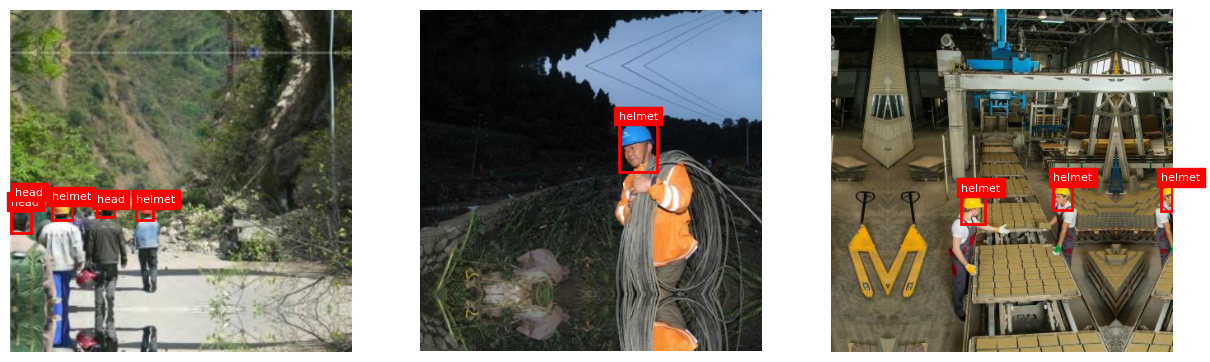


Validation Samples:


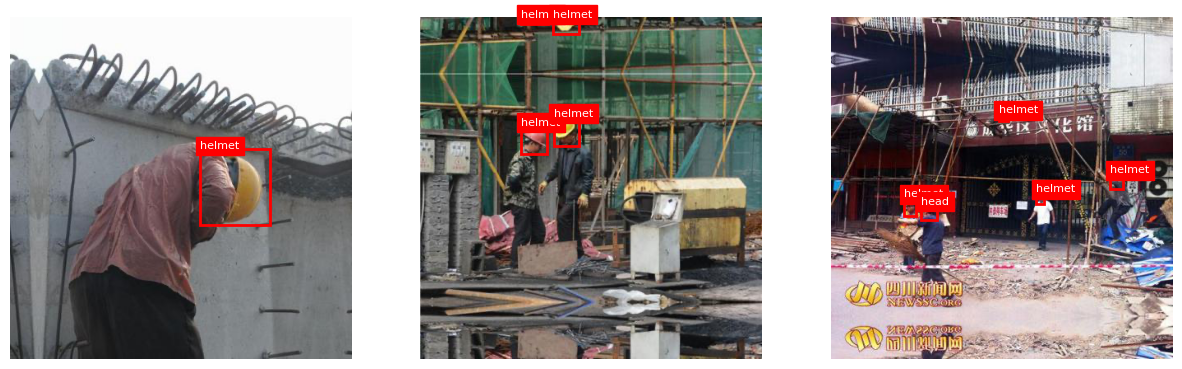


Test Samples:


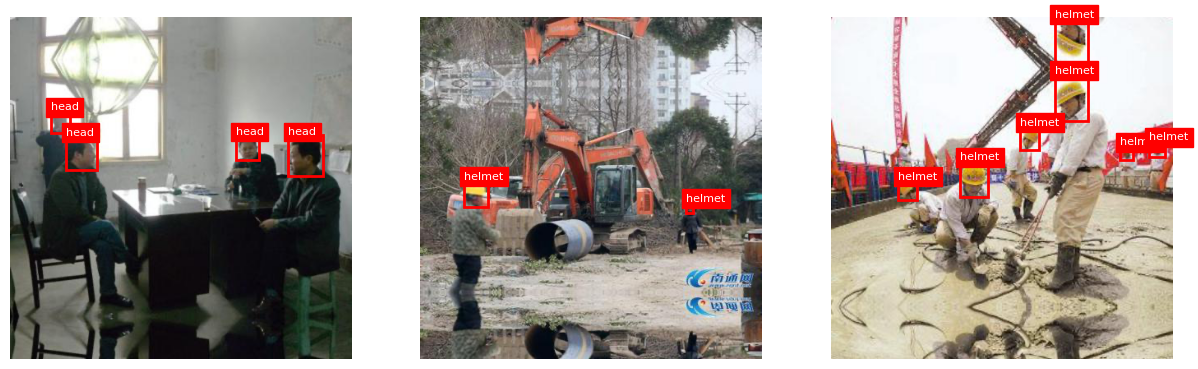

In [13]:
# %% 2-) Data Visualization
def plot_samples(data, num_samples=3):
    plt.figure(figsize=(15, 10))
    for idx, sample in enumerate(data[:num_samples]):
        image = cv2.imread(sample['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_samples, idx+1)
        plt.imshow(image)
        ax = plt.gca()
        
        for obj in sample['objects']:
            box = [obj['xmin'], obj['ymin'], obj['xmax'], obj['ymax']]
            rect = patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            plt.text(box[0], box[1], obj['name'], 
                     color='white', backgroundcolor='red', fontsize=8)
        plt.axis('off')
    plt.show()

print("Training Samples:")
plot_samples(train_data)
print("\nValidation Samples:")
plot_samples(val_data)
print("\nTest Samples:")
plot_samples(test_data)

In [14]:
# %% 3-) Modelling
class CustomRCNN(Model):
    def __init__(self, num_classes, input_shape=(416, 416, 3)):
        super().__init__()
        self.num_classes = num_classes
        
        # Feature extractor
        self.base_model = ResNet50(
            weights='imagenet', 
            include_top=False, 
            input_shape=input_shape
        )
        
        # Region proposal network
        self.rpn = tf.keras.Sequential([
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(9, (1, 1), activation='sigmoid')  # 9 anchors per position
        ])
        
        # Detection head
        self.detection_head = tf.keras.Sequential([
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dense(num_classes + 4, activation='softmax')  # 4 for bbox
        ])

    def call(self, inputs):
        features = self.base_model(inputs)
        rpn_output = self.rpn(features)
        return self.detection_head(rpn_output)

# Initialize model
num_classes = 3  # helmet, head, person
model = CustomRCNN(num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# %% Modified Data Pipeline
def create_dataset(data, batch_size=4):
    # First find max number of boxes in the dataset
    max_boxes = max(len(sample['objects']) for sample in data)
    
    class_map = {'helmet': 0, 'head': 1, 'person': 2}
    
    images = []
    boxes = []
    labels = []
    
    for sample in data:
        # Load and resize image
        image = tf.image.decode_jpeg(tf.io.read_file(sample['image_path']))
        image = tf.image.resize(image, (416, 416)) / 255.0
        
        # Process boxes with padding
        sample_boxes = []
        sample_labels = []
        for obj in sample['objects']:
            sample_boxes.append([
                obj['xmin'], obj['ymin'], 
                obj['xmax'], obj['ymax']
            ])
            sample_labels.append(class_map[obj['name']])
        
        # Pad to max_boxes
        num_padding = max_boxes - len(sample_boxes)
        sample_boxes += [[0, 0, 0, 0]] * num_padding  # Zero-padded boxes
        sample_labels += [-1] * num_padding  # -1 indicates padding
        
        images.append(image)
        boxes.append(tf.convert_to_tensor(sample_boxes, dtype=tf.float32))
        labels.append(tf.convert_to_tensor(sample_labels, dtype=tf.int32))
    
    return tf.data.Dataset.from_tensor_slices(
        (images, {'boxes': boxes, 'labels': labels})
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create datasets
train_ds = create_dataset(train_data)
val_ds = create_dataset(val_data)
test_ds = create_dataset(test_data)

: 

In [ ]:
# %% 5-) Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.h5', save_best_only=True, monitor='val_loss'),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2)
    ]
)

# Plot training history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()